# Simulate microscopic model (no space) with known parameters and see if mesoscopic SDE fitting can recover the parameters

In [2]:
%load_ext autoreload
%autoreload 2

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from scipy.special import comb
from itertools import combinations
from pathlib import Path

import sys
sys.path.append('../..')

from codebase.parameter_fitting import get_first_jump_moments, get_second_jump_moments, fit_alpha_beta_jointly_from_first_second_jump_moments

In [35]:
microscopic_params = pd.read_csv('../../Results/microscopic_params_full_dataset.csv').to_numpy()
fps = 121 # Hz, frame rate for experiments
fish_ages = [2, 4, 6, 8] # weeks

# timescales used to compute first, second jump moments for experiments
with open('../../Results/jump_moment_timescales.pkl', 'rb') as f:
    jump_moment_timescales = pickle.load(f)
agewise_dt1 = jump_moment_timescales['dt1'] # frames
agewise_dt2 = jump_moment_timescales['dt2'] # frames


In [36]:
agewise_dt1 

array([ 62,  63,  93, 103])

In [37]:
agewise_dt2

array([47, 21, 12,  9])

# Simulate microscopic dynamics under pairwise copying (no space) using Gillespie algorithm

In [38]:
def simulate_SDE_gillespie(N,s,eps,c,fps,T,seed=0):
    '''Simulate the SDE using the Gillespie algorithm.
    Parameters:
        N: number of fish
        s: angular diffusion rate
        eps: variance of angular diffusion 
        c: copying rate
        fps: frame rate for angular read out
        T: total simulation time
        seed: random seed
    Returns:
        theta: array of angles for each fish at each time step
        m_x: x-component of polarization
        m_y: y-component of polarization
    '''
    rng = np.random.default_rng(seed)

    dt = 1/fps # time step for readout
    theta = np.zeros((N,int(T/dt))) # (N, T/dt) for angles
    
    # initialize
    theta[:,0] = rng.random(N)*2*np.pi # random initial angles
    t= 0
    idx_0 = 0 #index for time steps

    # simulate using Gillespie algorithm
    while t < T:
        # --- 1. Compute propensities ---
        R_s = s * N          # total reorientation rate
        R_c = c * N          # total copying rate
        R_total = R_s + R_c

        if R_total == 0:
            break

        # --- 2. Draw waiting time ---
        tau = rng.exponential(1.0 / R_total)

        # propogate angles for all fish during waiting time
        idx_1 = min(idx_0 + np.ceil(tau/dt).astype(int), int(T/dt)-1) 
        theta[:,idx_0:idx_1+1] = theta[:,idx_0].reshape(-1, 1) # angles remain constant during waiting time

        t += tau
        if t >= T:
            break # event occurs after end of simulation, so we stop here

        # --- 3. Select which event fires ---
        if rng.random() < R_s / R_total:
            # Reorientation: pick a random fish and assign a random direction
            i = rng.integers(N)
            theta[i,idx_1] += rng.normal(0, np.sqrt(eps)) # angular diffusion
            theta[i,idx_1] = theta[i,idx_1] % (2*np.pi) # wrap angle to [0, 2pi)
        else:
            # Copying: pick a focal fish and a random neighbor
            i = rng.integers(N)
            j = rng.integers(N)   # may equal i (copies itself — no change). this is allowed in the derivation of SDE!
            theta[i,idx_1] = theta[j,idx_1]

        # --- 4. Update index ---
        idx_0 = idx_1
    
    # compute polarization
    m_x = np.mean(np.cos(theta), axis=0)
    m_y = np.mean(np.sin(theta), axis=0)
    return theta, m_x, m_y

Text(0, 0.5, 'polarization')

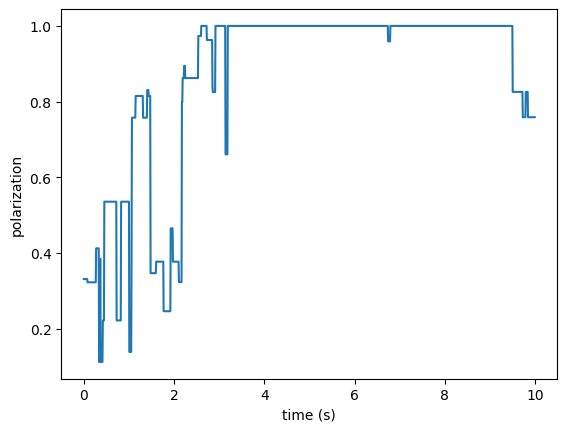

In [39]:
# Test

T = 600 #s
N = 4

# parameters from 8 wpf
j = 3
s = microscopic_params[j,0]
eps = microscopic_params[j,1]
c = microscopic_params[j,2]

theta, m_x,m_y = simulate_SDE_gillespie(N=N, s=s, eps=eps, c=c, fps=fps, T=T, seed=0)
polarization = np.sqrt(m_x**2 + m_y**2)
dt = 1/fps
plt.plot(np.arange(0,10,dt), polarization[:int(10/dt)])
plt.xlabel('time (s)')
plt.ylabel('polarization')

In [40]:
np.column_stack((m_x, m_y)).shape

(72600, 2)

# To test the validity of our fitting procedure, we will extract $\alpha, \beta$ from simulated data with known ground-truth for $N=2,3,4$
- For a fair comparison we will use the same amount of simulated data as that available from experiments, and use the same hyperparameters (i.e. time scales for computing jump moments) as used for the experiments
- Parameter error bars are estimated from subsampling simulations, as in the case of experimental data

In [41]:
def simulate_ground_truth_and_extract_params_subsamples(N, s, eps, c, fps, Tmax,nsims, nbins_fit, dt1, dt2):
    # grouth truth mesoscopic parameters
    alpha = s*(1-np.exp(-eps/2))
    beta = c
    
    first_jump_moments_all = []
    second_jump_moments_all = []
    for sim in range(nsims):
        theta, m_x, m_y = simulate_SDE_gillespie(N=N, s=s, eps=eps, c=c, fps=fps, T=Tmax, seed=sim)
        first_jump_moments = get_first_jump_moments([np.column_stack((m_x, m_y))], dt=dt1, fps=fps)
        second_jump_moments = get_second_jump_moments([np.column_stack((m_x, m_y))], dt=dt2, fps=fps)
        first_jump_moments_all.append(first_jump_moments)
        second_jump_moments_all.append(second_jump_moments)
    
    # subsample simulations
    sample_size = int(nsims/2)
    N_samples = int(comb(nsims, sample_size))
    fit_results = np.empty((N_samples,3)) #sample, (alpha, beta, R^2)

    for i,sample in enumerate(combinations(range(nsims), int(sample_size))):
        first_jump_moments_sampled = np.concatenate([first_jump_moments_all[ind] for ind in sample],axis=0)
        second_jump_moments_sampled = np.concatenate([second_jump_moments_all[ind] for ind in sample],axis=0)
        alpha_fit, beta_fit, r_squared = fit_alpha_beta_jointly_from_first_second_jump_moments(
            first_jump_moments_sampled, second_jump_moments_sampled, N=N, nbins=nbins_fit)
        fit_results[i,0] = alpha_fit
        fit_results[i,1] = beta_fit
        fit_results[i,2] = r_squared

    return fit_results


In [47]:
results_path = Path('../../Results/fitting_params_known_ground_truth.pkl')
if results_path.is_file():
    with open(results_path, 'rb') as f:
        results = pickle.load(f)
    ground_truth_alpha = results['ground_truth_alpha']
    ground_truth_beta = results['ground_truth_beta']
    fitted_alpha = results['fitted_alpha']
    fitted_beta = results['fitted_beta']
    N_list = results['N_list']
    nsims = results['nsims']
    Tmax = results['Tmax']
    fps = results['fps']

else:
    # dataset size matched to experiments
    Tmax = 600 #s
    nsims = 10
    fps = 121 # Hz

    fish_ages = [2,4,6,8]
    N_list = [2,3,4]

    # parameters matched to experiments
    ground_truth_alpha = microscopic_params[:,0]*(1-np.exp(-microscopic_params[:,1]/2))
    ground_truth_beta = microscopic_params[:,2]

    fitted_alpha = np.zeros((len(fish_ages), len(N_list),3)) # last dimension: mean, lower, upper bounds
    fitted_beta = np.zeros((len(fish_ages), len(N_list),3))

    for i, N in enumerate(N_list):
        for j, age in enumerate(fish_ages):
            s = microscopic_params[j,0]
            eps = microscopic_params[j,1]
            c = microscopic_params[j,2]
            dt1 = agewise_dt1[j] # frames
            dt2 = agewise_dt2[j] # frames

            fit_results = simulate_ground_truth_and_extract_params_subsamples(N=N, 
                                                                            s=s, 
                                                                            eps=eps, 
                                                                            c=c, 
                                                                            dt1=dt1, 
                                                                            dt2=dt2,
                                                                            Tmax=Tmax, 
                                                                            nsims=nsims, 
                                                                            nbins_fit=20, 
                                                                            fps = fps)
            fitted_alpha[j,i,:] = [np.mean(fit_results[:,0]), np.percentile(fit_results[:,0],2.5), np.percentile(fit_results[:,0],97.5)]
            fitted_beta[j,i,:] = [np.mean(fit_results[:,1]), np.percentile(fit_results[:,1],2.5), np.percentile(fit_results[:,1],97.5)]
            print(f'Completed N={N}, age={age}wpf')

    # save results
    results = {
        'ground_truth_alpha': ground_truth_alpha,
        'ground_truth_beta': ground_truth_beta,
        'fitted_alpha': fitted_alpha,
        'fitted_beta': fitted_beta,
        'N_list': N_list,
        'nsims': nsims,
        'Tmax': Tmax,
        'fps': fps
    }

    fname = f'../../Results/fitting_params_known_ground_truth.pkl'
    with open(fname, 'wb') as f:
        pickle.dump(results, f)

    

Completed N=2, age=2wpf
Completed N=2, age=4wpf
Completed N=2, age=6wpf


/Users/palka/Documents/Research/fish-school/data-analysis/danionella-collective-motion/Notebooks/Figure2/../../codebase/parameter_fitting.py:147: RuntimeWarning: invalid value encountered in sqrt
  B_yy2 = (dmyy + np.sqrt(dmxx*dmyy-dmxy**2))**2/((dmxx+dmyy)+2*np.sqrt(dmxx*dmyy-dmxy**2))
/Users/palka/Documents/Research/fish-school/data-analysis/danionella-collective-motion/Notebooks/Figure2/../../codebase/parameter_fitting.py:148: RuntimeWarning: invalid value encountered in sqrt
  return B_xx2, B_yy2, B_xy2
/Users/palka/Documents/Research/fish-school/data-analysis/danionella-collective-motion/Notebooks/Figure2/../../codebase/parameter_fitting.py:149: RuntimeWarning: invalid value encountered in sqrt
  


Completed N=2, age=8wpf
Completed N=3, age=2wpf
Completed N=3, age=4wpf
Completed N=3, age=6wpf
Completed N=3, age=8wpf
Completed N=4, age=2wpf
Completed N=4, age=4wpf
Completed N=4, age=6wpf
Completed N=4, age=8wpf


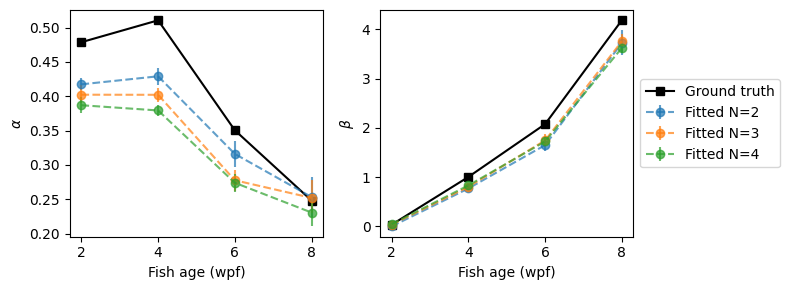

In [48]:
# plot fitted vs ground truth parameters
fig, ax = plt.subplots(1,2, figsize=(8,3))

ax[0].plot(fish_ages, ground_truth_alpha, 'k-', label='Ground truth', marker='s')
ax[1].plot(fish_ages, ground_truth_beta, 'k-', label='Ground truth', marker='s')
for i, N in enumerate(N_list):
    ax[0].errorbar(fish_ages, fitted_alpha[:,i,0], yerr=[fitted_alpha[:,i,0]-fitted_alpha[:,i,1],fitted_alpha[:,i,2]-fitted_alpha[:,i,0]], fmt='o--', label=f'Fitted N={N}', alpha=0.7)
    ax[1].errorbar(fish_ages, fitted_beta[:,i,0], yerr=[fitted_beta[:,i,0]-fitted_beta[:,i,1],fitted_beta[:,i,2]-fitted_beta[:,i,0]], fmt='o--', label=f'Fitted N={N}', alpha=0.7)
ax[0].set_xlabel('Fish age (wpf)')
ax[0].set_ylabel(r'$\alpha$')
ax[1].set_xlabel('Fish age (wpf)')
ax[1].set_ylabel(r'$\beta$')
# legend outside last plot
ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.tight_layout()